# Exercises

### Exercise 1
---
Use the sklearn `make_blobs()` function, in the same way that we used in the lesson, to generate a *non linearly separable* dataset with 2 features.  
Fit a linear SVM to the dataset many times, varying the slack hyperparameter $C$, and calculate the model performance in classifying the data.  
What is, approximately, a the best value of the $C$ hyperparameter for this dataset?

In [1]:
import os
os.chdir("C:/Users/larsb/Cognitive_neuroscience_RU/neuro-analysis-nongit/population-methods-main/02-SVM-decoding")

In [2]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
from sklearn import svm
import numpy as np
import pickle
import seaborn as sns
import sys
import os
sys.path.append(os.path.abspath("code"))
from utils import download_data
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(context='notebook',style='white',font_scale=1.5,
              rc = {'axes.spines.top':False,'axes.spines.right':False})

In [3]:
X_nsep,y_nsep = make_blobs(n_samples=100,n_features =2,centers=[[-1,0],[1,0]],cluster_std=.8)

In [48]:
def model_svm(slack):
    X,y = X_nsep,y_nsep
    svc_model = svm.SVC(kernel='linear',C=slack);
    svc_model.fit(X, y)
    accuracy = svc_model.score(X, y)

    return accuracy



In [49]:
full_acc = []
C_values = [0.00001, 0.01, 0.1, 1, 10, 100]
for i, C in enumerate(C_values):
    full_acc.append(model_svm(C))
    print(f"accuracy {C}: {full_acc[i]}")



accuracy 1e-05: 0.85
accuracy 0.01: 0.87
accuracy 0.1: 0.85
accuracy 1: 0.85
accuracy 10: 0.85
accuracy 100: 0.85


In [ ]:
# Of the tested values, 0.01 gives the highest accuracy for classifying the data,
# so a C hyperparameter value of 0.01 is approximatly the best value for this dataset
# However, the model was evaluated on the same data used for training, so the reported
# accuracy may overestimate its performance on unseen data.

### Exercise 2
---
Repeat exercise 1, but using a non-linear SVM model (the sklearn class `SVC` uses [Radial Basis Functions](https://en.wikipedia.org/wiki/Radial_basis_function) as a default, check its documentation [here](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html#sklearn.svm.SVC)). 
To have a fairer assessment of the performance, train the model on a fraction (e.g. 80%) of the data, and test it on the other 20%.
Compare the performance of a linear SVC and a RBF SVC for dataset that are increaslingly non-linearly-separable.


In [6]:
X_nsep,y_nsep = make_blobs(n_samples=100,n_features =2,centers=[[-1,0],[1,0]],cluster_std=.8)
X,y = X_nsep,y_nsep

In [7]:
from sklearn.model_selection import train_test_split
def l_model(nl, C):
    
    X_nsep,y_nsep = make_blobs(n_samples=100,n_features =2,centers=[[-1,0],[1,0]],cluster_std=0.8, random_state = 40)
    X,y = X_nsep,y_nsep

    X[:,0] = X[:, 0] + nl * X[:,1]**2

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size = 0.2, random_state = 40)
    
    svc_model = svm.SVC(kernel='linear',C=C);
    svc_model.fit(X_train, y_train)
    accuracy = svc_model.score(X_test, y_test)

    return accuracy
    


    



In [8]:

def non_l_model(nl, C):
    
    X_nsep,y_nsep = make_blobs(n_samples=100,n_features =2,centers=[[-1,0],[1,0]],cluster_std=0.8, random_state = 40)
    X,y = X_nsep,y_nsep

    X[:,0] = X[:, 0] + nl * X[:,1]**2

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size = 0.2, random_state = 40)

    svc_model = svm.SVC(kernel = "rbf", C=C, gamma = 'scale')
    svc_model.fit(X_train, y_train)
    accuracy = svc_model.score(X_test, y_test)

    return accuracy

    




In [9]:
C_values = [0.0001, 0.01, 0.1, 1, 10, 100]
nl_values = [0, 0.5, 1, 2]





In [10]:
for nl in nl_values:
    accuracy_l = []
    accuracy_non_l = []
    for C in C_values:
        accuracy_l.append(l_model(nl, C))
        accuracy_non_l.append(non_l_model(nl,C))
    best_C_l = C_values[np.argmax(accuracy_l)]
    best_C_non_l = C_values[np.argmax(accuracy_non_l)]

    max_acc_l = max(accuracy_l)
    max_acc_nl = max(accuracy_non_l)

    print(f"C value for max accuracy ({max_acc_l}) at non linearity {nl} = {best_C_l} linear model")
    print(f"C value for max accuracy ({max_acc_nl}) at non linearity {nl} = {best_C_non_l} non-linear model")


C value for max accuracy (0.85) at non linearity 0 = 1 linear model
C value for max accuracy (0.8) at non linearity 0 = 0.1 non-linear model
C value for max accuracy (0.8) at non linearity 0.5 = 0.01 linear model
C value for max accuracy (0.8) at non linearity 0.5 = 0.1 non-linear model
C value for max accuracy (0.75) at non linearity 1 = 1 linear model
C value for max accuracy (0.8) at non linearity 1 = 100 non-linear model
C value for max accuracy (0.6) at non linearity 2 = 0.1 linear model
C value for max accuracy (0.75) at non linearity 2 = 100 non-linear model


In [ ]:
# As the data becomes more non-linear, the RBF model performs better compared to the linear model. 
# With little or no non-linearity, the linear model performs equally well or slightly better. 
# At higher non-linearity, the RBF model reaches a higher accuracy. 
# For the RBF model, larger C values gave the best results at higher non-linearity. 
# A larger C punishes errors more strongly, so the model allows less slack. 
# For the linear model, there is no clear pattern between non-linearity and the best C value.


[-0.58699282 -0.72197367  0.74155355 -0.45009155  1.87944741  0.1176933
  1.07703482 -0.10001208 -0.07226317 -0.13417453 -0.76206199 -1.07409924
 -0.94155952 -0.23036145 -0.12543778 -0.32116782 -0.32511884 -1.1940866
 -0.45983082  0.01607023 -1.4964827  -1.84098169  1.28199747 -1.76876526
 -0.79194559 -0.46379815  0.48660356 -0.71018204  0.97915979 -1.26519651
 -1.4094547  -1.5745471   0.22282756  0.38941408 -1.10737167  0.821242
  0.42951561 -0.09245464 -0.86193331 -0.56850089  0.02329075 -0.35818788
 -0.60235643  0.85020867 -0.41128087  0.79593087  0.69243871 -1.14600274
 -0.52112354 -1.10022735  1.89292736  0.42800628 -1.10094682  0.64363155
 -0.59325171 -0.52021965 -0.97175444  0.16884558 -1.15330262 -1.32735811
  0.04828015  0.4744492   0.86252984  1.23558734  1.1256897   0.63463656
 -0.97131417 -0.00794392 -0.3083605   0.54066987 -1.23533689 -0.46284364
  0.78317142  0.06084063  0.93076722 -1.07655013 -1.60772772 -0.36469948
 -0.46159462 -1.58310613 -1.07481707 -1.70237335  1.368

### Exercise 3
---
Use the code below to simulate new data.
Generate data and then decode the stimulus identity, see how the decoding performance change when you change the following:

- The amplitude of the noise in the firing rate
- The amplitude of the stimulus modulation of the firing rate
- The number of neurons

Plot and comment.

In [50]:
# defining a function for generating the data
def generate_data(noise, sigma, cell_number):
    n_cells = cell_number; # number of cells to simulate
    n_stim_type = 2; # number of different stimuli
    sigma_stim = sigma # amplitude of stimulus related modulation
    average_firing_rate = 5; # average firing rate across the population

    # generate baseline rates from exponential distirbution
    cell_rate_baseline = np.random.exponential(average_firing_rate,size=n_cells)

    # create stimulus average responses, perturbing the population firng rate profile
    # we use a multiplicative modulation in opposite directions for the two stimuli
    modulation = sigma_stim*np.random.normal(0,1,size=n_cells)
    cell_rate_stim = {1: cell_rate_baseline * (1+modulation),2:cell_rate_baseline * (1-modulation)}
    # sets negative firng rate to 0
    cell_rate_stim[1][cell_rate_stim[1]<0]=0
    cell_rate_stim[2][cell_rate_stim[2]<0]=0

    s_rate = 10000 # the sampling rate of our emulated recording system
    noise_rate = noise # we are going to add some spike noise non related to the task
    n_stim = 100 # number of stimuli

    stim_dur = 2 #stimulus duration (in seconds)
    is_interval = 3 # interval between stimuli  (in seconds)

    stim_onsets = np.arange(0,n_stim*(stim_dur+is_interval),(stim_dur+is_interval)) # onset time of each stimulus (in seconds)
    stim_type = np.asarray([1 for i in range(int(n_stim/2))]+[2 for i in range(int(n_stim/2))]) # identity of each stimulus
    np.random.shuffle(stim_type)

    time = np.arange(0,(n_stim+1)*(stim_dur+is_interval),1.0/s_rate) # vector of the sampled times.

    spike_times = []
    for cell in range(n_cells):
        spikes = np.random.poisson((cell_rate_baseline[cell]+noise_rate)/s_rate,size=time.shape)
        for i,stimulus in enumerate(stim_type):
            stim_idxs = np.arange(stim_onsets[i]*s_rate,(stim_onsets[i]+stim_dur)*s_rate)
            spikes[stim_idxs] = np.random.poisson((cell_rate_stim[stimulus][cell]+noise_rate)/s_rate,size=stim_idxs.shape)

        spike_times.append(time[spikes>0])

    out_dict = {'spike_times':spike_times,
                'stim_onsets':stim_onsets,
                'stim_type':stim_type,
                'stim_duration':stim_dur
                 }

    return out_dict


        

In [51]:
# generating data with different noise values, with seed so that
# the data only differs in its noise
noise_values = [0, 2, 5, 10]
data = []
for noise in noise_values:
    np.random.seed(40)
    data.append(generate_data(noise, 0.5, 20))

In [37]:
# make a fucntion that decodes the data that is given as input, with
# an added seed for cross validation so that this is the same
from sklearn.model_selection import StratifiedKFold
from sklearn import svm
from sklearn.preprocessing import StandardScaler

def decode_data(current_data):
    data = current_data

    spike_times = data['spike_times']
    stim_onsets = data['stim_onsets']
    stim_type = data['stim_type']
    stim_duration = data['stim_duration']

    onset = 1 # in seconds before stimulus onset
    offset = 1 # in second after stimulus offset

    binwidth = 0.1 # in seconds (100 ms)
    bins = np.arange(-onset,stim_duration+offset+binwidth,binwidth)

    n_cells = len(spike_times)
    n_trials= len(stim_type)

    X = np.zeros((n_cells,n_trials,len(bins)-1));
    for cell in range(n_cells):    
        for trial in range(n_trials):

            # selects spikes that are in trial
            sp_idx = np.logical_and(spike_times[cell]>stim_onsets[trial]-onset,
                    spike_times[cell]<stim_onsets[trial]+stim_duration+offset)
            
            # centers spike times around stimulus onset
            sp_cntr = spike_times[cell][sp_idx]-stim_onsets[trial]
            #bins spikes
            spike_count,_ = np.histogram(sp_cntr,bins)
            #spike_count = zscore(spike_count)
            X[cell,trial,:] = spike_count

    n_splits = 5

    avg_performance = []
    std_performance = []

    for time_bin in range(X.shape[-1]):
            # setting 2-fold cross validation
            kf = StratifiedKFold(n_splits=n_splits,shuffle=True, random_state = 40)
            fold_performance = []

            for train_index, test_index in kf.split(X[:,:,time_bin].T,stim_type):
                    

                    X_train, X_test = X[:,train_index,time_bin].T, X[:,test_index,time_bin].T
                    y_train, y_test = stim_type[train_index], stim_type[test_index]

                    clf = svm.LinearSVC(max_iter=1000)
                    clf.fit(X_train, y_train)
                    fold_performance.append(clf.score(X_test,y_test))

            avg_performance.append(np.mean(fold_performance))
            std_performance.append(np.std(fold_performance))

    avg_performance = np.asarray(avg_performance)
    std_performance = np.asarray(std_performance)

    return avg_performance, std_performance, bins


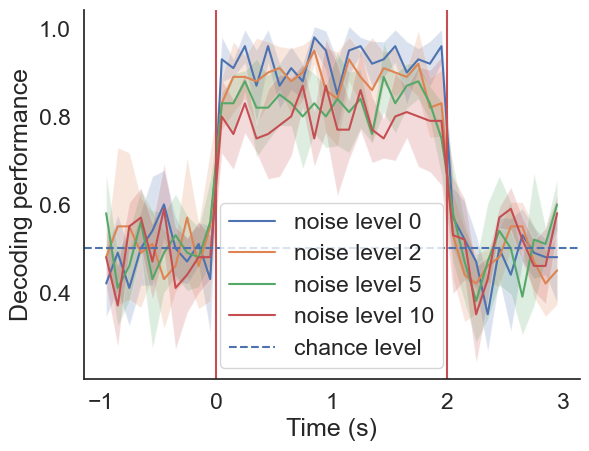

In [52]:
for i, current_data in enumerate(data):
    avg_performance, std_performance, bins = decode_data(current_data)

    bin_centers = [
        (bins[i + 1] + bins[i]) / 2
        for i in range(len(bins) - 1)
    ]

    plt.plot(bin_centers, avg_performance, label = f"noise level {noise_values[i]}")

    plt.fill_between(
        bin_centers,
        avg_performance - std_performance,
        avg_performance + std_performance,
        alpha=0.2
    )

plt.axvline(x=0, c='r')
plt.axvline(x=2, c='r')

plt.axhline(
    y=0.5,
    linestyle='--',
    label='chance level'
)

plt.xlabel('Time (s)')
plt.ylabel('Decoding performance')
plt.legend()
plt.show()

In [ ]:
# Increasing the noise level lowers decoding performance during stimulus presentation.
# With more noise, the spike counts become more variable, so the responses to stimulus 1
# and stimulus 2 overlap more and are harder for the decoder to distinguish.
# Noise level 0 gives the highest performance, while noise level 10 gives the lowest performance.

In [39]:
# Generating data that differs in amplitude of the 
# stimulus modulation of the firing rate
modulation_values = [0, 0.2, 0.5, 1]
data = []
for modulation in modulation_values:
    np.random.seed(40)
    data.append(generate_data(1, modulation, 20))


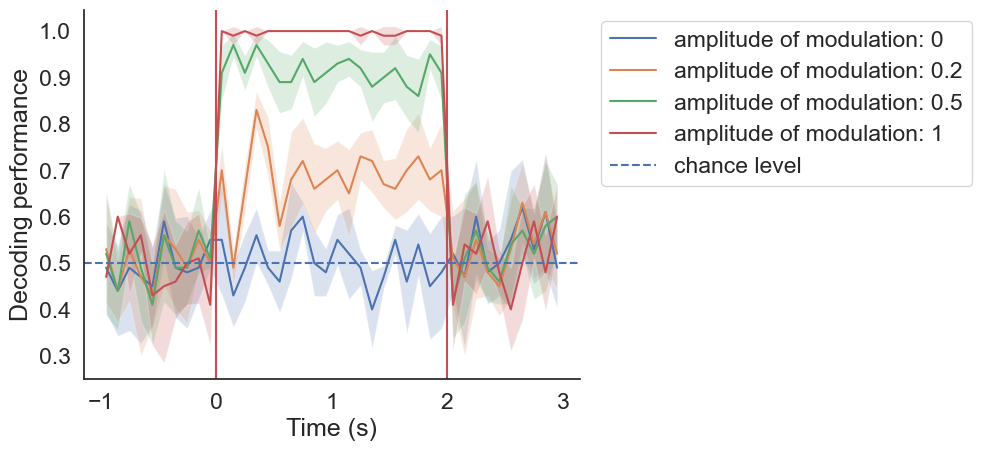

In [44]:
for i, current_data in enumerate(data):
    avg_performance, std_performance, bins = decode_data(current_data)

    bin_centers = [
        (bins[i + 1] + bins[i]) / 2
        for i in range(len(bins) - 1)
    ]

    plt.plot(bin_centers, avg_performance, label = f"amplitude of modulation: {modulation_values[i]}")

    plt.fill_between(
        bin_centers,
        avg_performance - std_performance,
        avg_performance + std_performance,
        alpha=0.2
    )

plt.axvline(x=0, c='r')
plt.axvline(x=2, c='r')

plt.axhline(
    y=0.5,
    linestyle='--',
    label='chance level'
)

plt.xlabel('Time (s)')
plt.ylabel('Decoding performance')
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
plt.show()

In [ ]:
# Because the firing rates are calculated as:
# cell_rate_stim = {1: cell_rate_baseline * (1 + modulation),
# 2: cell_rate_baseline * (1 - modulation)}
# a higher modulation amplitude increases the difference between stimulus 1 and stimulus 2.
# This makes the two stimuli easier to distinguish and therefore easier to decode.
# With no modulation, there is no difference between the two stimulus conditions,
# so decoding performance stays around chance level. 
# Higher modulation amplitudes result in better decoding performance.

In [46]:
# Generating data that differs in in its number of neurons
neuron_values = [5, 10, 20, 80]
data = []
for neuron in neuron_values:
    np.random.seed(40)
    data.append(generate_data(1, 0.5, neuron))

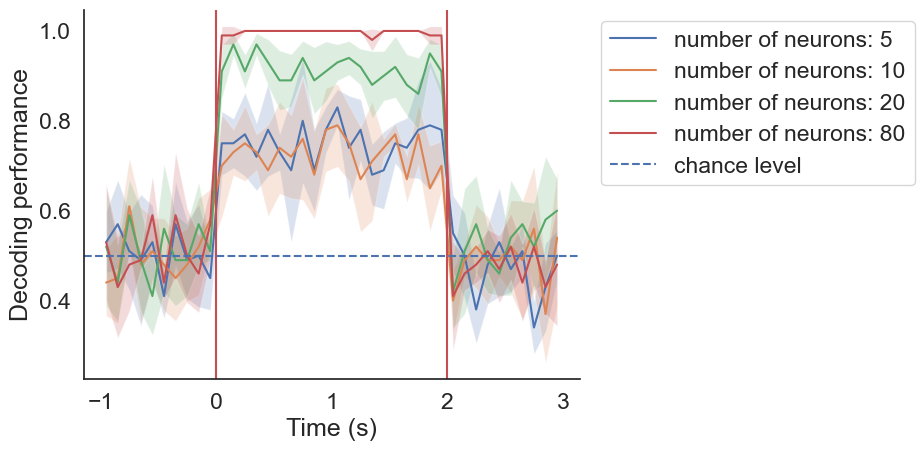

In [47]:
for i, current_data in enumerate(data):
    avg_performance, std_performance, bins = decode_data(current_data)

    bin_centers = [
        (bins[i + 1] + bins[i]) / 2
        for i in range(len(bins) - 1)
    ]

    plt.plot(bin_centers, avg_performance, label = f"number of neurons: {neuron_values[i]}")

    plt.fill_between(
        bin_centers,
        avg_performance - std_performance,
        avg_performance + std_performance,
        alpha=0.2
    )

plt.axvline(x=0, c='r')
plt.axvline(x=2, c='r')

plt.axhline(
    y=0.5,
    linestyle='--',
    label='chance level'
)

plt.xlabel('Time (s)')
plt.ylabel('Decoding performance')
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
plt.show()

In [ ]:
# Decoding performance improves as the number of neurons increases.
# With more neurons, the decoder receives more information about the stimulus,
# which makes stimulus 1 and stimulus 2 easier to distinguish.
# With 5 or 10 neurons, performance is lower and more variable.
# With 20 neurons, performance is already high, while 80 neurons gives almost perfect decoding.

## Useful code
---


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pickle

In [60]:
n_cells = 20; # number of cells to simulate
n_stim_type = 2; # number of different stimuli
sigma_stim = 0.5 # amplitude of stimulus related modulation
average_firing_rate = 5; # average firing rate across the population

# generate baseline rates from exponential distirbution
cell_rate_baseline = np.random.exponential(average_firing_rate,size=n_cells)

# create stimulus average responses, perturbing the population firng rate profile
# we use a multiplicative modulation in opposite directions for the two stimuli
modulation = sigma_stim*np.random.normal(0,1,size=n_cells)
cell_rate_stim = {1: cell_rate_baseline * (1+modulation),2:cell_rate_baseline * (1-modulation)}
# sets negative firng rate to 0
cell_rate_stim[1][cell_rate_stim[1]<0]=0
cell_rate_stim[2][cell_rate_stim[2]<0]=0

In [63]:
# simulate spiking activity

s_rate = 10000 # the sampling rate of our emulated recording system
noise_rate = 1 # we are going to add some spike noise non related to the task
n_stim = 100 # number of stimuli

stim_dur = 2 #stimulus duration (in seconds)
is_interval = 3 # interval between stimuli  (in seconds)

stim_onsets = np.arange(0,n_stim*(stim_dur+is_interval),(stim_dur+is_interval)) # onset time of each stimulus (in seconds)
stim_type = np.asarray([1 for i in range(int(n_stim/2))]+[2 for i in range(int(n_stim/2))]) # identity of each stimulus
np.random.shuffle(stim_type)

time = np.arange(0,(n_stim+1)*(stim_dur+is_interval),1.0/s_rate) # vector of the sampled times.

spike_times = []
for cell in range(n_cells):
    spikes = np.random.poisson(cell_rate_baseline[cell]/s_rate,size=time.shape)
    for i,stimulus in enumerate(stim_type):
        stim_idxs = np.arange(stim_onsets[i]*s_rate,(stim_onsets[i]+stim_dur)*s_rate)
        spikes[stim_idxs] = np.random.poisson(cell_rate_stim[stimulus][cell]/s_rate,size=stim_idxs.shape)

    spike_times.append(time[spikes>0])



In [3]:
# save ouput
out_dict = {'spike_times':spike_times,
            'stim_onsets':stim_onsets,
            'stim_type':stim_type,
            'stim_duration':stim_dur
            }

with open('data/simulated_data1.pickle', 'wb') as handle:
    pickle.dump(out_dict, handle, protocol=pickle.HIGHEST_PROTOCOL)


NameError: name 'spike_times' is not defined